In [26]:
# ============================================================
# Nav1.7 Small-Molecule Discovery
# Structural Ensemble Construction and Docking Validation
# ============================================================

"""
Project:
AI-assisted conformational ensemble docking for human Nav1.7

Current objectives:
1. Collect representative experimental Nav1.7 structures
2. Compare protein conformations using pairwise RMSD
3. Select representative conformations
4. Prepare receptor structures
5. Prepare experimental ligand levobupivacaine
6. Define docking pocket
7. Validate docking protocol by redocking
8. Prepare for ensemble virtual screening

Current working directory:
F:/大三秋/神秘比赛/clean_PDB/
"""

print("Nav1.7 ensemble docking project")
print("Stage: Structural analysis + docking validation")

Nav1.7 ensemble docking project
Stage: Structural analysis + docking validation


In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("Python environment ready.")

Python environment ready.


In [28]:
# Windows project directory
PROJECT_DIR = Path(r"F:\大三秋\神秘比赛")
CLEAN_DIR = PROJECT_DIR / "clean_PDB"

print("Project directory:")
print(PROJECT_DIR)

print("\nClean PDB directory:")
print(CLEAN_DIR)

Project directory:
F:\大三秋\神秘比赛

Clean PDB directory:
F:\大三秋\神秘比赛\clean_PDB


In [29]:
files = sorted(CLEAN_DIR.iterdir())

file_table = pd.DataFrame({
    "File": [f.name for f in files],
    "Type": [f.suffix for f in files],
    "Size_kB": [round(f.stat().st_size / 1024, 2) for f in files]
})

file_table

,File,Type,Size_kB
0,21TP_clean.pdb,.pdb,752.65
1,21TQ_clean.pdb,.pdb,794.34
2,7W9K_clean.pdb,.pdb,902.79
3,7W9T_clean.pdb,.pdb,903.34
4,8G1A_clean.pdb,.pdb,820.05
5,8I5B_receptor.pdb,.pdb,810.95
6,8I5B_receptor.pdbqt,.pdbqt,975.64
7,8I5B_redock.pdbqt,.pdbqt,21.70
8,bupivacaine.pdb,.pdb,2.20
9,bupivacaine.sdf,.sdf,1.84


In [30]:
structures = {
    "21TP": {
        "state": "Open-state",
        "pdb": "21TP_clean.pdb"
    },
    "21TQ": {
        "state": "Inactivation-associated",
        "pdb": "21TQ_clean.pdb"
    },
    "7W9K": {
        "state": "Apo / inactivated-like",
        "pdb": "7W9K_clean.pdb"
    },
    "7W9T": {
        "state": "S6IV alpha-helix",
        "pdb": "7W9T_clean.pdb"
    },
    "8G1A": {
        "state": "CBD-bound",
        "pdb": "8G1A_clean.pdb"
    }
}

structure_table = pd.DataFrame(structures).T
structure_table

,state,pdb
21TP,Open-state,21TP_clean.pdb
21TQ,Inactivation-associated,21TQ_clean.pdb
7W9K,Apo / inactivated-like,7W9K_clean.pdb
7W9T,S6IV alpha-helix,7W9T_clean.pdb
8G1A,CBD-bound,8G1A_clean.pdb


In [32]:
names = [
    "21TP", "21TQ", "7W9K", "7W9M",
    "7W9P", "7W9T", "8G1A", "8I5B", "8THH"
]

rmsd = np.array([
    [0,     1.762, 1.930, 2.150, 2.264, 1.961, 2.038, 2.038, 2.038],
    [1.762, 0,     1.487, 1.912, 1.658, 1.379, 1.630, 1.575, 1.575],
    [1.930, 1.487, 0,     4.349, 3.369, 2.825, 1.648, 1.270, 1.317],
    [2.150, 1.912, 3.369, 0,     4.401, 4.798, 2.022, 1.441, 1.512],
    [2.264, 1.658, 3.369, 4.401, 0,     2.206, 2.138, 1.560, 1.596],
    [1.961, 1.379, 2.825, 4.798, 2.206, 0,     4.910, 1.520, 1.583],
    [2.038, 1.630, 1.648, 2.022, 2.138, 4.910, 0,     4.384, 2.893],
    [2.038, 1.575, 1.270, 1.441, 1.560, 1.520, 4.384, 0,     6.109],
    [2.038, 1.575, 1.317, 1.512, 1.596, 1.583, 2.893, 6.109, 0]
])

rmsd_df = pd.DataFrame(rmsd, index=names, columns=names)

rmsd_df

,21TP,21TQ,7W9K,7W9M,7W9P,7W9T,8G1A,8I5B,8THH
21TP,0.000,1.762,1.930,2.150,2.264,1.961,2.038,2.038,2.038
21TQ,1.762,0.000,1.487,1.912,1.658,1.379,1.630,1.575,1.575
7W9K,1.930,1.487,0.000,4.349,3.369,2.825,1.648,1.270,1.317
7W9M,2.150,1.912,3.369,0.000,4.401,4.798,2.022,1.441,1.512
7W9P,2.264,1.658,3.369,4.401,0.000,2.206,2.138,1.560,1.596
7W9T,1.961,1.379,2.825,4.798,2.206,0.000,4.910,1.520,1.583
8G1A,2.038,1.630,1.648,2.022,2.138,4.910,0.000,4.384,2.893
8I5B,2.038,1.575,1.270,1.441,1.560,1.520,4.384,0.000,6.109
8THH,2.038,1.575,1.317,1.512,1.596,1.583,2.893,6.109,0.000


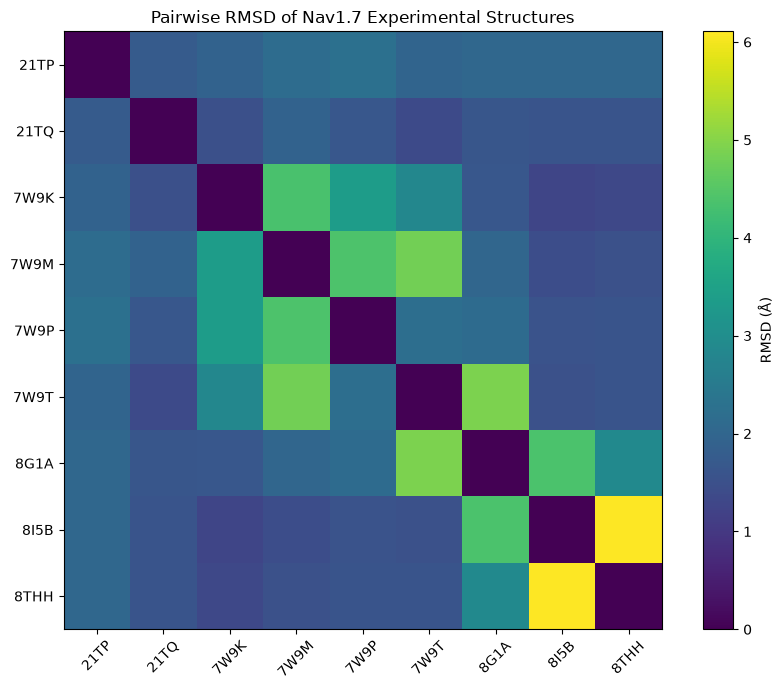

In [33]:
plt.figure(figsize=(9, 7))

plt.imshow(rmsd_df.values)

plt.xticks(range(len(names)), names, rotation=45)
plt.yticks(range(len(names)), names)

plt.colorbar(label="RMSD (Å)")
plt.title("Pairwise RMSD of Nav1.7 Experimental Structures")

plt.tight_layout()
plt.show()

In [34]:
mean_rmsd = (
    rmsd_df.replace(0, np.nan)
    .mean(axis=1)
    .sort_values()
)

mean_rmsd

21TQ    1.622250
21TP    2.022625
7W9K    2.274375
8THH    2.327875
7W9P    2.399000
8I5B    2.487125
7W9T    2.647750
7W9M    2.700625
8G1A    2.707875
dtype: float64

In [35]:
pairs = []

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        pairs.append({
            "Structure 1": names[i],
            "Structure 2": names[j],
            "RMSD (Å)": rmsd[i, j]
        })

pair_df = pd.DataFrame(pairs)

print("Most similar pairs:")
display(pair_df.sort_values("RMSD (Å)").head(10))

print("\nMost different pairs:")
display(pair_df.sort_values("RMSD (Å)", ascending=False).head(10))

Most similar pairs:


,Structure 1,Structure 2,RMSD (Å)
19,7W9K,8I5B,1.270
20,7W9K,8THH,1.317
11,21TQ,7W9T,1.379
24,7W9M,8I5B,1.441
8,21TQ,7W9K,1.487
25,7W9M,8THH,1.512
31,7W9T,8I5B,1.520
28,7W9P,8I5B,1.560
13,21TQ,8I5B,1.575
14,21TQ,8THH,1.575



Most different pairs:


,Structure 1,Structure 2,RMSD (Å)
35,8I5B,8THH,6.109
30,7W9T,8G1A,4.910
22,7W9M,7W9T,4.798
21,7W9M,7W9P,4.401
33,8G1A,8I5B,4.384
15,7W9K,7W9M,4.349
16,7W9K,7W9P,3.369
34,8G1A,8THH,2.893
17,7W9K,7W9T,2.825
3,21TP,7W9P,2.264


In [36]:
ensemble_summary = pd.DataFrame([
    ["21TP", "Open-state", "Veratridine-activated open pore", "Core"],
    ["21TQ", "Inactivation-associated", "Veratridine near IFM / site I", "Core"],
    ["7W9K", "Apo / inactivated-like", "Ligand-free reference-like structure", "Core"],
    ["7W9T", "S6IV alpha-helix", "Distinct S6IV local conformation", "Core"],
    ["8G1A", "CBD-bound", "Ligand-associated inactivated conformation", "Core"],
    ["8I5B", "Bupivacaine/levobupivacaine-bound", "Experimental ligand-bound structure", "Validation"],
    ["8THH", "Lamotrigine-bound", "Dual-pocket ligand-bound structure", "Validation"],
    ["7W9M", "E406K + ProTx-II + TTX", "Mutant/toxin structure", "Excluded"],
    ["7W9P", "E406K + HWTX-IV + STX", "Mutant/toxin structure", "Excluded"],
], columns=[
    "PDB", "Structural interpretation",
    "Biological context", "Role in project"
])

ensemble_summary

,PDB,Structural interpretation,Biological context,Role in project
0,21TP,Open-state,Veratridine-activated open pore,Core
1,21TQ,Inactivation-associated,Veratridine near IFM / site I,Core
2,7W9K,Apo / inactivated-like,Ligand-free reference-like structure,Core
3,7W9T,S6IV alpha-helix,Distinct S6IV local conformation,Core
4,8G1A,CBD-bound,Ligand-associated inactivated conformation,Core
5,8I5B,Bupivacaine/levobupivacaine-bound,Experimental ligand-bound structure,Validation
6,8THH,Lamotrigine-bound,Dual-pocket ligand-bound structure,Validation
7,7W9M,E406K + ProTx-II + TTX,Mutant/toxin structure,Excluded
8,7W9P,E406K + HWTX-IV + STX,Mutant/toxin structure,Excluded


In [37]:
receptor_files = [
    "21TP_clean.pdb",
    "21TQ_clean.pdb",
    "7W9K_clean.pdb",
    "7W9T_clean.pdb",
    "8G1A_clean.pdb",
    "8I5B_receptor.pdb"
]

receptor_status = []

for f in receptor_files:
    path = CLEAN_DIR / f
    receptor_status.append({
        "File": f,
        "Exists": path.exists(),
        "Size_kB": round(path.stat().st_size / 1024, 2)
        if path.exists() else None
    })

pd.DataFrame(receptor_status)

,File,Exists,Size_kB
0,21TP_clean.pdb,True,752.65
1,21TQ_clean.pdb,True,794.34
2,7W9K_clean.pdb,True,902.79
3,7W9T_clean.pdb,True,903.34
4,8G1A_clean.pdb,True,820.05
5,8I5B_receptor.pdb,True,810.95


In [39]:
pdbqt_files = [
    "8I5B_receptor.pdbqt",
    "levobupivacaine.pdbqt"
]

pdbqt_status = []

for f in pdbqt_files:
    path = CLEAN_DIR / f
    pdbqt_status.append({
        "File": f,
        "Exists": path.exists(),
        "Size_kB": round(path.stat().st_size / 1024, 2)
        if path.exists() else None
    })

pd.DataFrame(pdbqt_status)

,File,Exists,Size_kB
0,8I5B_receptor.pdbqt,True,975.64
1,levobupivacaine.pdbqt,True,2.15


In [40]:
ligand_files = [
    "levobupivacaine.sdf",
    "levobupivacaine.pdbqt",
    "bupivacaine.pdb",
]

ligand_status = []

for f in ligand_files:
    path = CLEAN_DIR / f
    
    ligand_status.append({
        "File": f,
        "Exists": path.exists(),
        "Size_kB": round(path.stat().st_size / 1024, 2)
        if path.exists() else None
    })

pd.DataFrame(ligand_status)

,File,Exists,Size_kB
0,levobupivacaine.sdf,True,4.16
1,levobupivacaine.pdbqt,True,2.15
2,bupivacaine.pdb,True,2.20


In [41]:
box = {
    "center_x": 124.036,
    "center_y": 122.846,
    "center_z": 104.507,
    "size_x": 20,
    "size_y": 20,
    "size_z": 20
}

box_df = pd.DataFrame([box])

box_df

,center_x,center_y,center_z,size_x,size_y,size_z
0,124.036,122.846,104.507,20,20,20


In [42]:
redocking_results = pd.DataFrame({
    "Mode": range(1, 10),
    "Affinity_kcal_mol": [
        -6.756,
        -6.719,
        -6.716,
        -6.695,
        -6.695,
        -6.671,
        -6.619,
        -6.555,
        -6.274
    ],
    "RMSD_lower_bound": [
        0,
        2.84,
        0.2857,
        3.031,
        3.931,
        1.664,
        1.67,
        3.99,
        3.458
    ],
    "RMSD_upper_bound": [
        0,
        5.51,
        1.904,
        6.02,
        5.508,
        5.809,
        5.98,
        5.24,
        6.399
    ]
})

redocking_results

,Mode,Affinity_kcal_mol,RMSD_lower_bound,RMSD_upper_bound
0,1,-6.756,0.0000,0.000
1,2,-6.719,2.8400,5.510
2,3,-6.716,0.2857,1.904
3,4,-6.695,3.0310,6.020
4,5,-6.695,3.9310,5.508
5,6,-6.671,1.6640,5.809
6,7,-6.619,1.6700,5.980
7,8,-6.555,3.9900,5.240
8,9,-6.274,3.4580,6.399


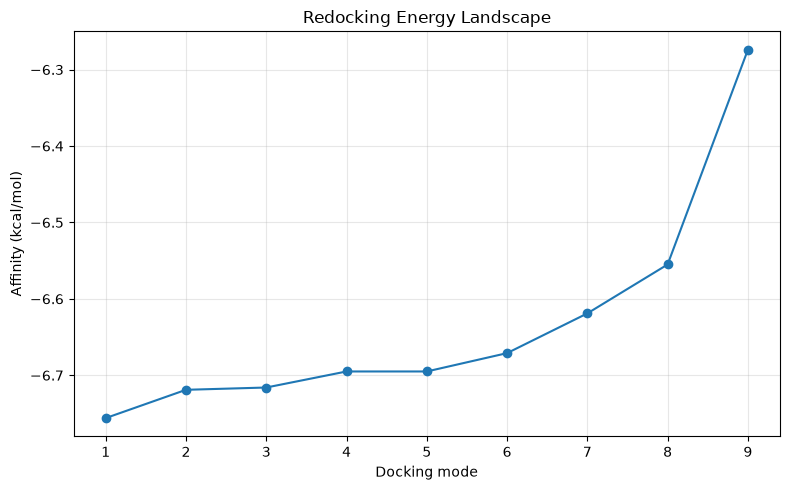

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    redocking_results["Mode"],
    redocking_results["Affinity_kcal_mol"],
    marker="o"
)

plt.xlabel("Docking mode")
plt.ylabel("Affinity (kcal/mol)")
plt.title("Redocking Energy Landscape")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()